# A2C policy for swing-up control

The objective of this notebook is to train and evaluate an Advantage Actor-Critic (A2C) controller for the unbalanced disk swing-up task. The controller must move the disk from the lower position to the upright position while respecting the input limit of ±3 V.

The notebook is written as a small design story. First, a simple reward is tried without observation noise. This gives a baseline policy and shows what happens when the reward mainly encourages reaching the top. Afterwards, a shaped reward is trained, also without observation noise, so that the effect of reward shaping can be compared fairly. At the end, the selected shaped-reward policy is trained once more with angular-velocity observation noise. That final version is intended for the real lab setup, where measurements are less ideal than in simulation.


## 1. Setup

The state observation is represented as

$$x_k = [\sin(\theta_k),\cos(\theta_k),\omega_k].$$

The sine-cosine representation avoids a discontinuity when the angle crosses ±π. The action is the motor voltage $u_k$, which is clipped by the environment to the allowed range of ±3 V.

The first two policies are trained without artificial observation noise. This keeps the simple-reward and shaped-reward comparison clean. A final robust policy is then trained with noise on the angular-velocity observation, because this is closer to the real experimental setup.


In [1]:
from pathlib import Path
import importlib
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

import a2c_unbalanced_disk_train as disk_rl
importlib.reload(disk_rl)

EPISODES = 1000
EPISODE_STEPS = disk_rl.EPISODE_STEPS
SIMULATION_STEPS = disk_rl.DEFAULT_SIMULATION_STEPS
ENTROPY_COEF = 0.005
DEVICE = "cpu"  # A2C with an MLP policy is usually faster and more stable on CPU for this setup.

NO_OMEGA_NOISE = 0.0
ROBUST_OMEGA_NOISE = disk_rl.OBS_NOISE_OMEGA

MODEL_PATH = Path("simple_a2c_zip_models/a2c_unbalanced_disk_report")
SIMPLE_MODEL_PATH = Path("simple_a2c_zip_models/a2c_unbalanced_disk_simple_reward")
ROBUST_MODEL_PATH = Path("simple_a2c_zip_models/a2c_unbalanced_disk_report_omega_noise")

print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(f"device: {DEVICE}")
print(f"episodes: {EPISODES}")
print(f"episode steps: {EPISODE_STEPS}")
print(f"total timesteps: {EPISODES * EPISODE_STEPS:,}")
print(f"entropy coefficient: {ENTROPY_COEF}")
print(f"simple/shaped comparison omega noise std: {NO_OMEGA_NOISE}")
print(f"robust policy omega noise std: {ROBUST_OMEGA_NOISE}")
print(f"shaped reward weights: {disk_rl.REWARD_WEIGHTS}")


torch: 2.12.0
cuda available: False
device: cpu
episodes: 1000
episode steps: 300
total timesteps: 300,000
entropy coefficient: 0.005
simple/shaped comparison omega noise std: 0.0
robust policy omega noise std: 0.1
shaped reward weights: {'swing_up': 0.5, 'capture': 12.0, 'top_speed_penalty': 1.5, 'omega_penalty': 0.03, 'action_penalty': 0.001, 'stall_penalty': 0.5}


## 2. First attempt: simple reward

The first reward mainly encourages the disk to move towards the upright position. It uses the smooth term

$$\left(\frac{1-\cos(\theta)}{2}\right)^2,$$

which is close to zero near the bottom and close to one near the top. Small penalties on angular velocity and voltage are added, but there is no separate capture bonus around the upright position.

This simple reward may be enough to discover swing-up motion, but it may not give enough feedback for balancing once the disk reaches the top.


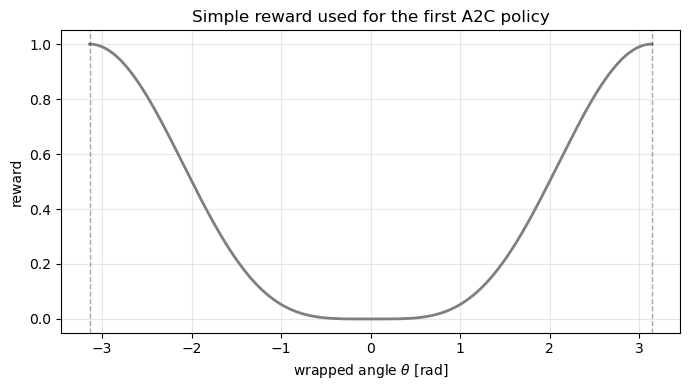

In [2]:
def simple_balance_reward(theta, omega, action, umax):
    theta_wrapped = disk_rl.wrap_angle(theta)
    swing_up_reward = ((1.0 - np.cos(theta_wrapped)) / 2.0) ** 2
    omega_penalty = (omega / 10.0) ** 2
    action_penalty = (action / umax) ** 2
    return swing_up_reward - 0.03 * omega_penalty - 0.001 * action_penalty

theta_grid = np.linspace(-np.pi, np.pi, 400)
simple_curve = [simple_balance_reward(theta, omega=0.0, action=0.0, umax=3.0) for theta in theta_grid]

plt.figure(figsize=(7, 4))
plt.plot(theta_grid, simple_curve, color="tab:gray", linewidth=2.0)
plt.axvline(np.pi, color="k", linestyle="--", linewidth=1, alpha=0.35)
plt.axvline(-np.pi, color="k", linestyle="--", linewidth=1, alpha=0.35)
plt.xlabel(r"wrapped angle $\theta$ [rad]")
plt.ylabel("reward")
plt.title("Simple reward used for the first A2C policy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Training with the simple reward

The simple-reward policy is trained first, without angular-velocity observation noise. This gives a clean baseline for judging whether the more detailed reward shaping is useful. The actor is stochastic during training, and the entropy term encourages exploration.


In [3]:
class EpisodeReturnCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.timesteps = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            episode = info.get("episode")
            if episode is not None:
                self.episode_returns.append(float(episode["r"]))
                self.episode_lengths.append(int(episode["l"]))
                self.timesteps.append(int(self.num_timesteps))
        return True


class SimpleRewardDiskEnv(disk_rl.DiskSB3Env):
    def step(self, action):
        u = float(np.asarray(action, dtype=np.float32).reshape(-1)[0])
        obs, env_reward, terminated, truncated, info = self.env.step(u)

        theta = self.env.unwrapped.th
        omega = self.env.unwrapped.omega
        theta_wrapped = disk_rl.wrap_angle(theta)
        upright_error = np.pi - abs(theta_wrapped)
        train_reward = simple_balance_reward(theta, omega, u, self.umax)

        info = {
            **info,
            "theta": float(theta),
            "theta_wrapped": float(theta_wrapped),
            "omega": float(omega),
            "upright_error": float(upright_error),
            "env_reward": float(env_reward),
            "train_reward": float(train_reward),
        }
        return self._add_observation_noise(obs), float(train_reward), terminated, truncated, info


def make_simple_env(seed=disk_rl.SEED, max_episode_steps=EPISODE_STEPS, obs_noise_omega=NO_OMEGA_NOISE):
    def _init():
        env = SimpleRewardDiskEnv(max_episode_steps=max_episode_steps, obs_noise_omega=obs_noise_omega)
        env = disk_rl.Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

simple_train_env = DummyVecEnv([make_simple_env(disk_rl.SEED, EPISODE_STEPS, NO_OMEGA_NOISE)])
simple_model = disk_rl.build_model(simple_train_env, DEVICE, ENTROPY_COEF)
simple_callback = EpisodeReturnCallback()

t0 = time.perf_counter()
simple_model.learn(total_timesteps=EPISODES * EPISODE_STEPS, callback=simple_callback, progress_bar=True)
simple_elapsed = time.perf_counter() - t0
SIMPLE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
simple_model.save(SIMPLE_MODEL_PATH)
simple_train_env.close()

print(f"simple reward training time: {simple_elapsed:.1f}s ({EPISODES * EPISODE_STEPS / simple_elapsed:.1f} steps/s)")
print(f"saved simple reward model: {SIMPLE_MODEL_PATH}.zip")
print(f"recorded simple reward episodes: {len(simple_callback.episode_returns)}")


/Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

simple reward training time: 312.9s (958.7 steps/s)
saved simple reward model: simple_a2c_zip_models/a2c_unbalanced_disk_simple_reward.zip
recorded simple reward episodes: 1000


## 4. Simple-reward policy evaluation

The simple policy is evaluated deterministically. This removes exploration noise and shows the controller that would be applied after training. The most important quantities are the final upright error and the fraction of the rollout spent within ±15 degrees of the upright position.


In [4]:
def rollout_arrays(model, max_steps=EPISODE_STEPS, deterministic=True, obs_noise_omega=0.0, seed=None):
    env = disk_rl.DiskSB3Env(max_episode_steps=max_steps, obs_noise_omega=obs_noise_omega)
    obs, _ = env.reset(seed=seed)
    rewards, actions, infos = [], [], []
    try:
        for _ in range(max_steps):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(float(reward))
            actions.append(float(np.asarray(action).reshape(-1)[0]))
            infos.append(info)
            if terminated or truncated:
                break
    finally:
        env.close()

    data = {
        "rewards": np.asarray(rewards),
        "actions": np.asarray(actions),
        "theta": np.array([info["theta_wrapped"] for info in infos]),
        "upright_error": np.array([info["upright_error"] for info in infos]),
        "omega": np.array([info["omega"] for info in infos]),
        "env_rewards": np.array([info["env_reward"] for info in infos]),
    }
    return data


def summarize_rollout(label, data):
    within_15 = np.mean(data["upright_error"] <= np.deg2rad(15.0)) * 100
    summary = {
        "steps": len(data["rewards"]),
        "external return": float(np.sum(data["rewards"])),
        "environment return": float(np.sum(data["env_rewards"])),
        "mean upright error [rad]": float(np.mean(data["upright_error"])),
        "final upright error [rad]": float(data["upright_error"][-1]),
        "time within 15 deg [%]": float(within_15),
        "max |omega| [rad/s]": float(np.max(np.abs(data["omega"]))),
        "max |u| [V]": float(np.max(np.abs(data["actions"]))),
    }
    print(f"=== {label} ===")
    for key, value in summary.items():
        if key == "steps":
            print(f"{key}: {value}")
        else:
            print(f"{key}: {value:.3f}")
    return summary

simple_eval_data = rollout_arrays(simple_model, max_steps=EPISODE_STEPS, deterministic=True, obs_noise_omega=0.0, seed=disk_rl.SEED + 1)
simple_eval_summary = summarize_rollout("simple reward deterministic rollout", simple_eval_data)


=== simple reward deterministic rollout ===
steps: 300
external return: -75.938
environment return: 0.001
mean upright error [rad]: 2.407
final upright error [rad]: 2.412
time within 15 deg [%]: 0.000
max |omega| [rad/s]: 6.353
max |u| [V]: 3.000


**Interpretation.** The simple reward baseline should be judged mainly by whether it reaches the upright region and whether it can stay there. If the final upright error is small but the time inside the ±15 degree band is limited, then the reward encourages swing-up but does not give enough guidance for balancing.


## 5. Improved shaped reward

The second reward keeps the swing-up term but adds more structure near the upright position. A capture bonus rewards being close to the top with low angular velocity. A top-speed penalty discourages fast motion near the upright equilibrium, while the action penalty discourages unnecessarily large voltages.

This reward is more directly connected to the final control objective: the disk should not only reach the top, but also remain close to it with controlled velocity.


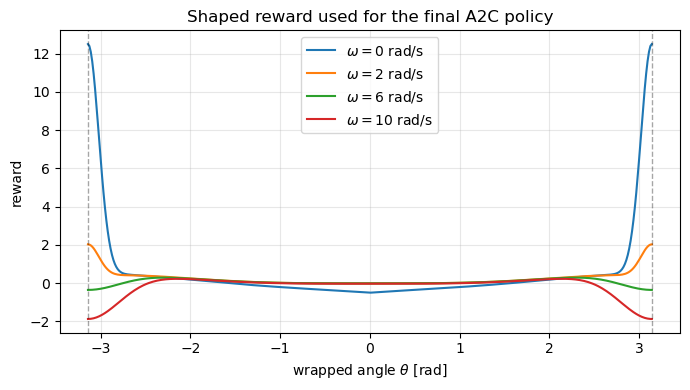

In [5]:
shaped_omega_levels = [0.0, 2.0, 6.0, 10.0]

plt.figure(figsize=(7, 4))
for omega in shaped_omega_levels:
    shaped_curve = [disk_rl.external_balance_reward(theta, omega, action=0.0, umax=3.0) for theta in theta_grid]
    plt.plot(theta_grid, shaped_curve, label=fr"$\omega={omega:.0f}$ rad/s")

plt.axvline(np.pi, color="k", linestyle="--", linewidth=1, alpha=0.35)
plt.axvline(-np.pi, color="k", linestyle="--", linewidth=1, alpha=0.35)
plt.xlabel(r"wrapped angle $\theta$ [rad]")
plt.ylabel("reward")
plt.title("Shaped reward used for the final A2C policy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Training with the shaped reward

The second policy is trained with the shaped reward and again without angular-velocity observation noise. Using the same noise setting as the simple baseline keeps the comparison focused on the reward design. The same A2C settings are used.


In [6]:
train_env = DummyVecEnv([disk_rl.make_env(disk_rl.SEED, EPISODE_STEPS, NO_OMEGA_NOISE)])
model = disk_rl.build_model(train_env, DEVICE, ENTROPY_COEF)
callback = EpisodeReturnCallback()

t0 = time.perf_counter()
model.learn(total_timesteps=EPISODES * EPISODE_STEPS, callback=callback, progress_bar=True)
elapsed = time.perf_counter() - t0
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
train_env.close()

print(f"training time: {elapsed:.1f}s ({EPISODES * EPISODE_STEPS / elapsed:.1f} steps/s)")
print(f"saved model: {MODEL_PATH}.zip")
print(f"recorded episodes: {len(callback.episode_returns)}")


training time: 105.3s (2848.9 steps/s)
saved model: simple_a2c_zip_models/a2c_unbalanced_disk_report.zip
recorded episodes: 1000


## 7. Shaped-reward policy evaluation

The shaped-reward policy is evaluated with the same deterministic procedure as the simple policy. This makes the final comparison fair: both policies are tested on the same task, with the same episode length and without exploration noise.


In [7]:
eval_data = rollout_arrays(model, max_steps=EPISODE_STEPS, deterministic=True, obs_noise_omega=0.0, seed=disk_rl.SEED + 1)
eval_summary = summarize_rollout("shaped reward deterministic rollout", eval_data)


=== shaped reward deterministic rollout ===
steps: 300
external return: 2233.838
environment return: 235.318
mean upright error [rad]: 0.492
final upright error [rad]: 0.088
time within 15 deg [%]: 78.000
max |omega| [rad/s]: 12.715
max |u| [V]: 3.000


**Result.** The shaped-reward policy is the main simulation controller. It should be judged by the final upright error, the time spent inside the ±15 degree upright band, and whether the input remains within the allowed ±3 V range. These metrics are compared directly with the simple-reward policy below.


## 8. Learning progress comparison

The two training curves compare the simple reward baseline and the shaped reward. The reward scales are not identical, so the absolute returns should not be compared too directly. The important point is the learning trend and whether each policy improves during training.


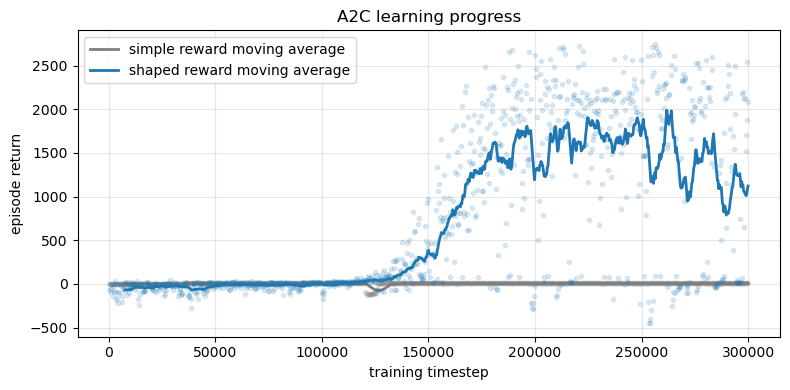

In [8]:
def moving_average(x, window=25):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    window = min(window, len(x))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def plot_training_history(cb, label, color=None, window=25):
    returns = np.asarray(cb.episode_returns, dtype=float)
    timesteps = np.asarray(cb.timesteps, dtype=float)
    if len(returns) == 0:
        print(f"No training history found for {label}.")
        return
    returns_ma = moving_average(returns, window)
    t_ma = timesteps[window - 1:] if len(timesteps) >= window else timesteps
    plt.plot(timesteps, returns, ".", alpha=0.15, color=color)
    plt.plot(t_ma, returns_ma, linewidth=2.0, color=color, label=f"{label} moving average")

plt.figure(figsize=(8, 4))
plot_training_history(simple_callback, "simple reward", color="tab:gray")
plot_training_history(callback, "shaped reward", color="tab:blue")
plt.xlabel("training timestep")
plt.ylabel("episode return")
plt.title("A2C learning progress")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Result.** The learning curves compare the effect of the reward design under the same no-noise training condition. The shaped reward is expected to give a more useful learning signal near the upright position because it explicitly rewards capture with low angular velocity. The simple reward is mainly a baseline that shows what happens when this extra guidance is removed.


## 9. Direct policy comparison

The table below compares the deterministic rollout metrics of the simple-reward and shaped-reward policies. The shaped policy is selected if it gives a smaller upright error and spends more time inside the ±15 degree upright band.


In [9]:
comparison_rows = [
    ("simple reward", simple_eval_summary),
    ("shaped reward", eval_summary),
]

print("policy          return     mean err   final err   within 15 deg   max |omega|   max |u|")
for name, summary in comparison_rows:
    print(
        f"{name:<14} "
        f"{summary['external return']:>8.1f}   "
        f"{summary['mean upright error [rad]']:>8.3f}   "
        f"{summary['final upright error [rad]']:>9.3f}   "
        f"{summary['time within 15 deg [%]']:>12.1f}   "
        f"{summary['max |omega| [rad/s]']:>10.2f}   "
        f"{summary['max |u| [V]']:>7.2f}"
    )


policy          return     mean err   final err   within 15 deg   max |omega|   max |u|
simple reward     -75.9      2.407       2.412            0.0         6.35      3.00
shaped reward    2233.8      0.492       0.088           78.0        12.72      3.00


## 10. Swing-up trajectory of the selected policy

The following plot summarizes the closed-loop behavior of the shaped-reward policy, which is the selected controller. The upright error shows whether the disk reaches the top, the angular velocity shows whether the motion remains controlled, and the voltage plot shows how strongly the actuator is used. The dashed line in the first panel marks the ±15 degree band around the upright position.


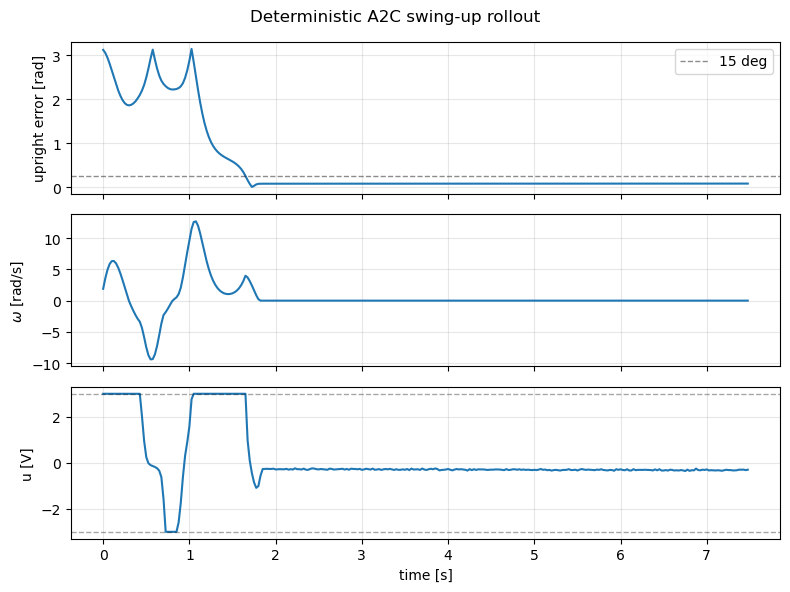

In [10]:
time_axis = np.arange(len(eval_data["rewards"])) * 0.025
upright_band = np.deg2rad(15.0)

fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

axs[0].plot(time_axis, eval_data["upright_error"])
axs[0].axhline(upright_band, color="k", linestyle="--", linewidth=1, alpha=0.45, label="15 deg")
axs[0].set_ylabel("upright error [rad]")
axs[0].legend(loc="upper right")
axs[0].grid(alpha=0.3)

axs[1].plot(time_axis, eval_data["omega"])
axs[1].set_ylabel(r"$\omega$ [rad/s]")
axs[1].grid(alpha=0.3)

axs[2].plot(time_axis, eval_data["actions"])
axs[2].axhline(3.0, color="k", linestyle="--", linewidth=1, alpha=0.35)
axs[2].axhline(-3.0, color="k", linestyle="--", linewidth=1, alpha=0.35)
axs[2].set_ylabel("u [V]")
axs[2].set_xlabel("time [s]")
axs[2].set_ylim(-3.3, 3.3)
axs[2].grid(alpha=0.3)

fig.suptitle("Deterministic A2C swing-up rollout")
fig.tight_layout()
plt.show()


## 11. Stochastic and deterministic policy comparison

The actor is stochastic during learning, but the deterministic action is normally preferred for deployment. To check the effect of this choice, both modes are evaluated over several episodes for the shaped-reward policy. The comparison gives the mean and standard deviation of the main performance metrics.


In [11]:
def repeated_evaluation(model, deterministic, n_runs=20):
    rows = []
    for run in range(n_runs):
        data = rollout_arrays(
            model,
            max_steps=EPISODE_STEPS,
            deterministic=deterministic,
            obs_noise_omega=0.0,
            seed=disk_rl.SEED + 100 + run,
        )
        rows.append([
            np.sum(data["rewards"]),
            np.mean(data["upright_error"]),
            data["upright_error"][-1],
            np.mean(data["upright_error"] <= np.deg2rad(15.0)) * 100,
            np.max(np.abs(data["actions"])),
        ])
    return np.asarray(rows)

metrics = ["return", "mean upright error", "final upright error", "within 15 deg [%]", "max |u|"]
det_eval = repeated_evaluation(model, deterministic=True, n_runs=20)
stoch_eval = repeated_evaluation(model, deterministic=False, n_runs=20)

print("metric                     deterministic mean ± std        stochastic mean ± std")
for i, metric in enumerate(metrics):
    print(
        f"{metric:<26} "
        f"{det_eval[:, i].mean():>9.3f} ± {det_eval[:, i].std():<8.3f} "
        f"{stoch_eval[:, i].mean():>9.3f} ± {stoch_eval[:, i].std():<8.3f}"
    )


metric                     deterministic mean ± std        stochastic mean ± std
return                      2232.300 ± 32.040    1482.089 ± 634.778 
mean upright error             0.492 ± 0.002        0.677 ± 0.229   
final upright error            0.088 ± 0.002        0.169 ± 0.197   
within 15 deg [%]             77.850 ± 0.196       62.833 ± 25.714  
max |u|                        3.000 ± 0.000        3.000 ± 0.000   


**Result.** The deterministic policy is expected to be more consistent than the stochastic policy because exploration noise is removed. For deployment, the deterministic action is therefore used.


## 12. Learned policy map

A trajectory plot shows what the policy does from one initial condition. To better understand the learned controller, the deterministic action is also evaluated on a grid of angle and angular velocity values. This gives a slice of the actor over the state space and shows where it applies positive voltage, negative voltage, or saturates at the input limits.


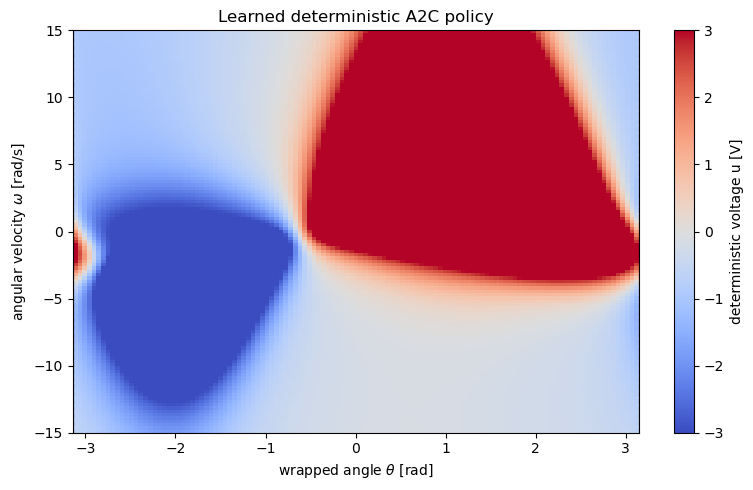

In [12]:
def deterministic_action_for_state(model, theta, omega):
    obs = np.array([np.sin(theta), np.cos(theta), omega], dtype=np.float32)
    action, _ = model.predict(obs, deterministic=True)
    return float(np.asarray(action).reshape(-1)[0])

theta_vals = np.linspace(-np.pi, np.pi, 121)
omega_vals = np.linspace(-15.0, 15.0, 121)
policy_u = np.zeros((len(omega_vals), len(theta_vals)))

for i, omega in enumerate(omega_vals):
    for j, theta in enumerate(theta_vals):
        policy_u[i, j] = deterministic_action_for_state(model, theta, omega)

plt.figure(figsize=(8, 5))
im = plt.imshow(
    policy_u,
    origin="lower",
    extent=[theta_vals[0], theta_vals[-1], omega_vals[0], omega_vals[-1]],
    aspect="auto",
    cmap="coolwarm",
    vmin=-3,
    vmax=3,
)
plt.colorbar(im, label="deterministic voltage u [V]")
plt.axvline(np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
plt.axvline(-np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
plt.xlabel(r"wrapped angle $\theta$ [rad]")
plt.ylabel(r"angular velocity $\omega$ [rad/s]")
plt.title("Learned deterministic A2C policy")
plt.tight_layout()
plt.show()


## 13. Final robust policy for the lab setup

The simple and shaped policies above were trained without artificial observation noise so that the reward-design comparison was clean. For the actual lab experiment, the angular-velocity measurement is less ideal. Therefore, the selected shaped-reward policy is trained once more with noise added to the angular-velocity observation during training.

The reward and A2C settings are kept the same as for the selected shaped policy. Only the training observation is made noisier. The goal is to obtain a controller that is less sensitive to measurement errors when it is transferred from simulation to the physical setup.


In [13]:
robust_train_env = DummyVecEnv([disk_rl.make_env(disk_rl.SEED, EPISODE_STEPS, ROBUST_OMEGA_NOISE)])
robust_model = disk_rl.build_model(robust_train_env, DEVICE, ENTROPY_COEF)
robust_callback = EpisodeReturnCallback()

t0 = time.perf_counter()
robust_model.learn(total_timesteps=EPISODES * EPISODE_STEPS, callback=robust_callback, progress_bar=True)
robust_elapsed = time.perf_counter() - t0
ROBUST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
robust_model.save(ROBUST_MODEL_PATH)
robust_train_env.close()

print(f"robust training time: {robust_elapsed:.1f}s ({EPISODES * EPISODE_STEPS / robust_elapsed:.1f} steps/s)")
print(f"saved robust model: {ROBUST_MODEL_PATH}.zip")
print(f"recorded robust episodes: {len(robust_callback.episode_returns)}")


robust training time: 164.3s (1826.2 steps/s)
saved robust model: simple_a2c_zip_models/a2c_unbalanced_disk_report_omega_noise.zip
recorded robust episodes: 1000


### Robust policy evaluation

The robust policy is evaluated twice. First, it is tested without artificial observation noise to check that it still solves the nominal simulation task. Second, it is tested with angular-velocity observation noise to check whether the policy remains usable under the type of measurement uncertainty expected in the real setup.


In [14]:
robust_eval_nominal = rollout_arrays(
    robust_model,
    max_steps=EPISODE_STEPS,
    deterministic=True,
    obs_noise_omega=NO_OMEGA_NOISE,
    seed=disk_rl.SEED + 1,
)
robust_eval_noisy = rollout_arrays(
    robust_model,
    max_steps=EPISODE_STEPS,
    deterministic=True,
    obs_noise_omega=ROBUST_OMEGA_NOISE,
    seed=disk_rl.SEED + 1,
)

robust_summary_nominal = summarize_rollout("robust policy, nominal evaluation", robust_eval_nominal)
robust_summary_noisy = summarize_rollout("robust policy, noisy-omega evaluation", robust_eval_noisy)


=== robust policy, nominal evaluation ===
steps: 300
external return: 19.861
environment return: 1.285
mean upright error [rad]: 1.959
final upright error [rad]: 1.364
time within 15 deg [%]: 0.000
max |omega| [rad/s]: 10.890
max |u| [V]: 3.000
=== robust policy, noisy-omega evaluation ===
steps: 300
external return: 19.887
environment return: 1.313
mean upright error [rad]: 1.957
final upright error [rad]: 1.327
time within 15 deg [%]: 0.000
max |omega| [rad/s]: 10.948
max |u| [V]: 3.000


**Result.** The robust policy is the version intended for the physical lab experiment. If its nominal performance remains close to the no-noise shaped policy and its noisy evaluation remains stable, then adding angular-velocity noise during training is justified.


## 14. Optional loading and visual simulation

The saved policies can be loaded for repeated evaluation without retraining. A longer rendered simulation can also be used for visual inspection, but the numerical evaluation above is the main evidence for the learned policy.


In [15]:
# Load instead of retraining, if needed:
# simple_model = A2C.load(SIMPLE_MODEL_PATH, device=DEVICE)
# model = A2C.load(MODEL_PATH, device=DEVICE)

# Render a longer simulation, if visual inspection is needed:
# sim_rewards, sim_actions, sim_infos = disk_rl.rollout(
#     model,
#     max_steps=SIMULATION_STEPS,
#     deterministic=True,
#     render=True,
#     obs_noise_omega=0.0,
# )
# sim_data = {
#     "rewards": sim_rewards,
#     "actions": sim_actions,
#     "theta": np.array([info["theta_wrapped"] for info in sim_infos]),
#     "upright_error": np.array([info["upright_error"] for info in sim_infos]),
#     "omega": np.array([info["omega"] for info in sim_infos]),
#     "env_rewards": np.array([info["env_reward"] for info in sim_infos]),
# }
# summarize_rollout("long deterministic simulation", sim_data)
